In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('/home/kyomukama/ACE/camonet/ml (NEW)/Data all.csv')

In [5]:
data.describe()

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,referral,ward,antib_prior_admi,sympt_dura,hiv_status,...,Prescribed_antib_1,Prescribed_antib_2,Prescribed_antib_3,organism_isolated,first_organism,sec_organism,Resistance,Antibioitic_aft_cul_1,complications,length_hosp_stay
count,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,...,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000
mean,3.931208,30.179530,0.516779,5.872483,4.055369,0.280201,2.634228,0.817114,1.751678,1.187919,...,6.466443,11.382550,5.518456,1.484899,12.758389,9.795302,0.479866,13.704698,0.191275,22.578859
std,2.372170,22.903443,0.500138,3.156508,1.164729,0.449475,1.305619,0.636516,1.110113,0.915738,...,6.221990,6.552795,3.775373,1.430087,4.626414,1.805234,0.500014,3.424584,0.393636,39.681067
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,12.000000,0.000000,4.000000,4.000000,0.000000,2.000000,0.000000,1.000000,0.000000,...,3.000000,7.000000,3.000000,0.000000,10.000000,10.000000,0.000000,15.000000,0.000000,6.000000
50%,4.000000,28.000000,1.000000,6.000000,4.000000,0.000000,3.000000,1.000000,2.000000,2.000000,...,3.000000,7.000000,3.000000,1.000000,13.000000,10.000000,0.000000,15.000000,0.000000,14.000000
75%,6.000000,44.000000,1.000000,8.000000,4.000000,1.000000,4.000000,1.000000,2.000000,2.000000,...,8.000000,20.000000,11.000000,3.000000,13.000000,10.000000,1.000000,15.000000,0.000000,27.000000
max,8.000000,95.000000,1.000000,11.000000,10.000000,1.000000,4.000000,2.000000,4.000000,2.000000,...,22.000000,22.000000,14.000000,3.000000,23.000000,17.000000,1.000000,17.000000,1.000000,744.000000


In [6]:
data.head()

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,referral,ward,antib_prior_admi,sympt_dura,hiv_status,...,Prescribed_antib_1,Prescribed_antib_2,Prescribed_antib_3,organism_isolated,first_organism,sec_organism,Resistance,Antibioitic_aft_cul_1,complications,length_hosp_stay
0,0,6.0,0,1,4,1,3,1,2,2,...,17,7,3,3,13,10,0,15,0,12.0
1,0,13.0,0,6,6,1,2,1,0,0,...,11,7,3,3,13,10,0,15,0,8.0
2,0,11.0,0,11,4,0,3,1,2,2,...,3,4,3,3,13,10,0,15,1,14.0
3,0,18.0,0,10,4,1,4,1,2,2,...,21,14,3,0,4,10,1,15,1,0.0
4,0,17.0,1,10,4,1,1,1,2,1,...,5,20,11,0,9,10,1,6,1,10.0


In [5]:
data.columns

Index(['name_of_rrh', 'age', 'sex', 'Infection_Site_1', 'Infection_Site_2',
       'Infection_Site_3', 'referral', 'ward', 'antib_prior_admi',
       'Prio_antib_1', 'Prio_antib_2', 'Prio_antib_3', 'Prio_antib_4',
       'sympt_dura', 'hiv_status', 'intubated', 'Comobidity1', 'Comobidity2',
       'Comobidity3', 'antibiotics', 'Prescribed_antib_1',
       'Prescribed_antib_2', 'Prescribed_antib_3', 'Prescribed_antib_4',
       'Prescribed_antib_5', 'organism_isolated', 'growth1', 'first_organism',
       'Resistance1 ', 'sec_organism', 'Resistance2', 'third_organism',
       'Resistance3', 'antib_aft_culture', 'Antibioitic_aft_cul_1',
       'Antibioitic_aft_cul_2', 'complications', 'me_complic',
       'treatment_outcome', 'length_hosp_stay'],
      dtype='object')

In [6]:
data.drop(columns =['me_complic'], inplace = True)

# EDA

In [7]:
data.shape

(599, 39)

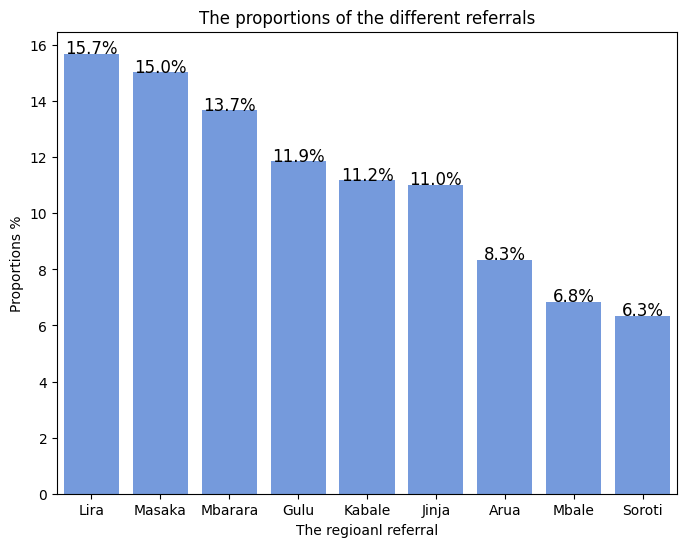

In [8]:
referral_count = data['name_of_rrh'].value_counts(normalize = True) * 100

plt.figure(figsize = (8,6))

ax = sns.barplot(x = referral_count.index, y = referral_count.values, color = 'cornflowerblue')

plt.title("The proportions of the different referrals")
plt.xlabel('The regioanl referral')
plt.ylabel("Proportions %")

# Show percentage values on bars
for i, val in enumerate(referral_count.values):
    plt.text(i, val, f"{val:.1f}%", ha='center', fontsize=12)
    

plt.show()

In [9]:
data['age'].describe()

count    598.000000
mean      30.272575
std       22.906648
min        0.000000
25%       12.000000
50%       28.000000
75%       44.000000
max       95.000000
Name: age, dtype: float64

In [10]:
data[data['age'].isna()].index

Int64Index([567], dtype='int64')

In [11]:
data['age'] = data['age'].fillna(data['age'].median())

Text(0.5, 1.0, 'Age distribution')

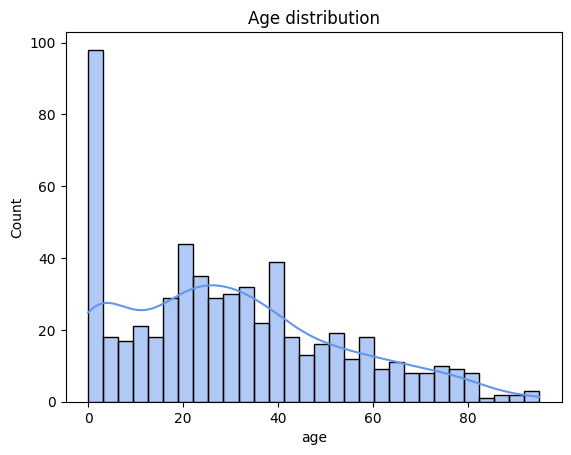

In [12]:
sns.histplot(data, x= 'age', bins = 30, kde = True, color = 'cornflowerblue')

plt.title("Age distribution")

In [13]:
data['sex'].info

<bound method Series.info of 0        Male
1        Male
2        Male
3        Male
4      Female
        ...  
594    Female
595    Female
596    Female
597    Female
598    Female
Name: sex, Length: 599, dtype: object>

/tmp/ipykernel_11079/332617357.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(x = sex_count.index, y = sex_count.values, palette = 'Set1')


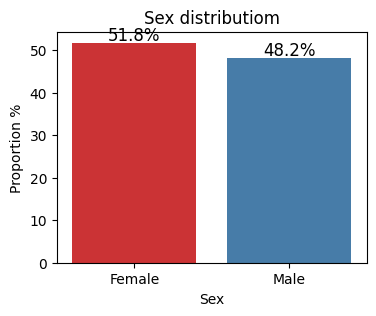

In [14]:
sex_count = data['sex'].value_counts(normalize = True)* 100

plt.figure(figsize = (4,3))

ax =sns.barplot(x = sex_count.index, y = sex_count.values, palette = 'Set1')

plt.title('Sex distributiom')
plt.xlabel('Sex')
plt.ylabel('Proportion %')

# Show percentage values on bars
for i, val in enumerate(sex_count.values):
    plt.text(i, val + 0.5, f"{val:.1f}%", ha='center', fontsize=12)

plt.show()

<Axes: xlabel='name_of_rrh', ylabel='age'>

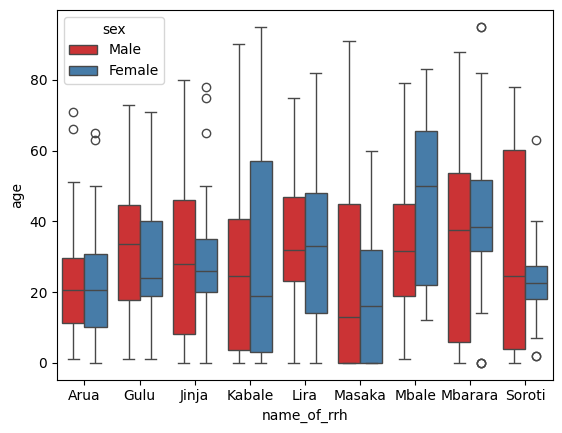

In [15]:
sns.boxplot(data, x= 'name_of_rrh', y = 'age', hue = 'sex', palette= 'Set1')

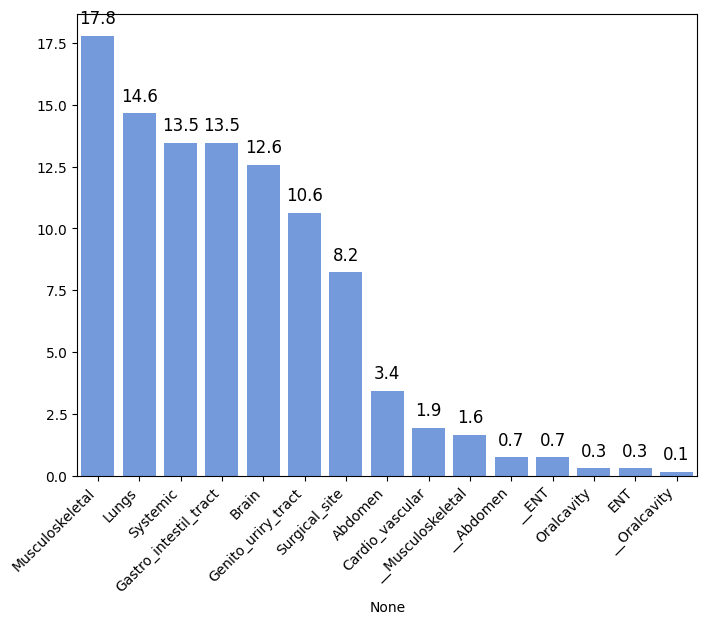

In [16]:
infection = pd.melt(
    data,
    id_vars = 'ward',
    value_vars= ['Infection_Site_1', 'Infection_Site_2', 'Infection_Site_3'],
    value_name= 'Infections'
)

infection.dropna(subset = 'Infections')

plt.figure(figsize = (8,6))

infection_count = infection['Infections'].value_counts(normalize = True)* 100

sns.barplot(x = infection_count.index , y = infection_count.values , color = 'cornflowerblue')

plt.xticks(rotation = 45, ha = 'right')

# Show percentage values on bars
for i, val in enumerate(infection_count.values):
    plt.text(i, val + 0.5, f"{val:.1f}", ha='center', fontsize=12)

plt.show()

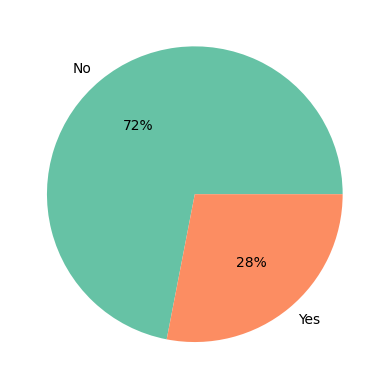

In [17]:
# define Seaborn color palette to use 
palette_color = sns.color_palette('Set2') 
referral_count =  data['referral'].value_counts(normalize = True)*100
  
# plotting data on chart 
plt.pie(referral_count.values, labels= referral_count.index, colors=palette_color, autopct='%.0f%%') 
  
# displaying chart 
plt.show() 

<function matplotlib.pyplot.show(close=None, block=None)>

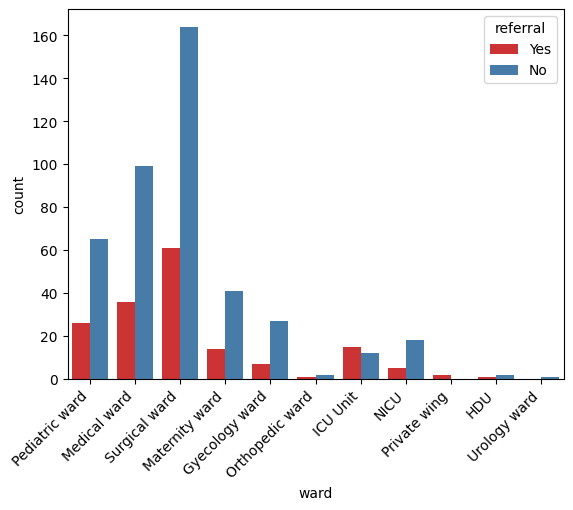

In [18]:
sns.countplot(data, x = 'ward', hue = 'referral', palette = 'Set1')

plt.xticks(rotation = 45, ha ='right')

plt.show

<Axes: xlabel='referral', ylabel='length_hosp_stay'>

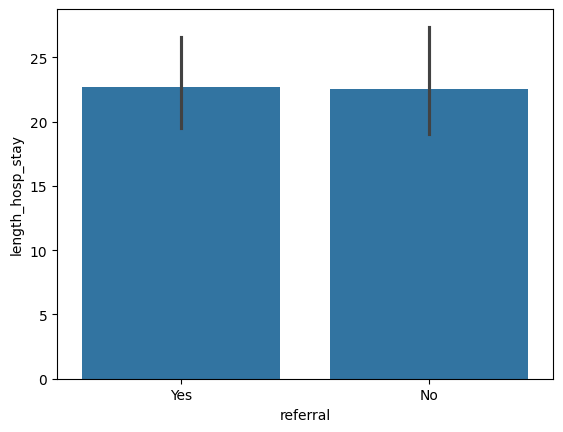

In [19]:
sns.barplot(data, x= 'referral', y = 'length_hosp_stay')

<Axes: xlabel='hiv_status', ylabel='length_hosp_stay'>

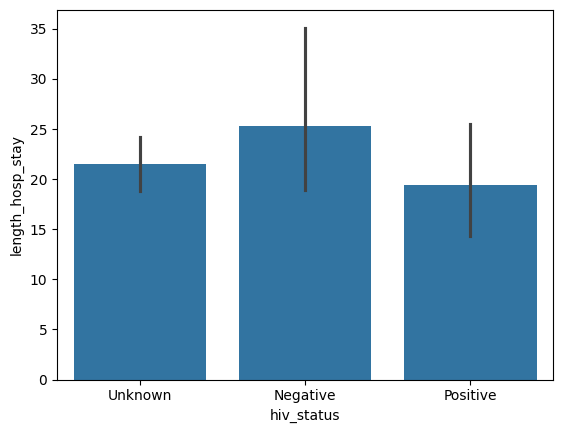

In [20]:
sns.barplot(data, x= 'hiv_status', y = 'length_hosp_stay')

In [21]:
data['intubated'] = data['intubated'].replace({'Unknown': 'No'})

<Axes: xlabel='intubated', ylabel='length_hosp_stay'>

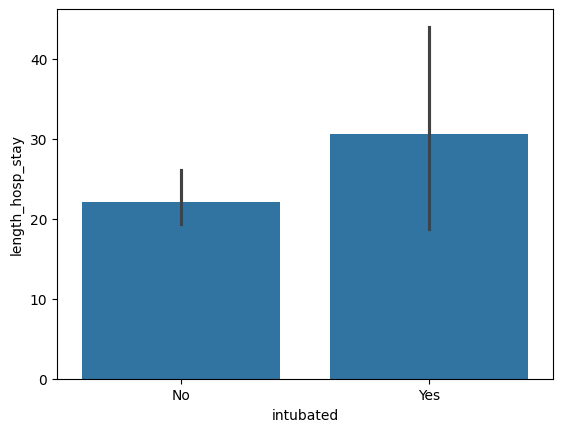

In [22]:
sns.barplot(data, x= 'intubated', y = 'length_hosp_stay')

In [23]:
def resitance_check (row) :
    if any(row[['Resistance1 ', 'Resistance2', 'Resistance3']] =='Yes'):
        return 'Yes'
    else:
        return 'No'
    
# Create a new column 'resistance' using the function
data['resistance'] = data.apply(resitance_check, axis=1)

<Axes: xlabel='resistance', ylabel='length_hosp_stay'>

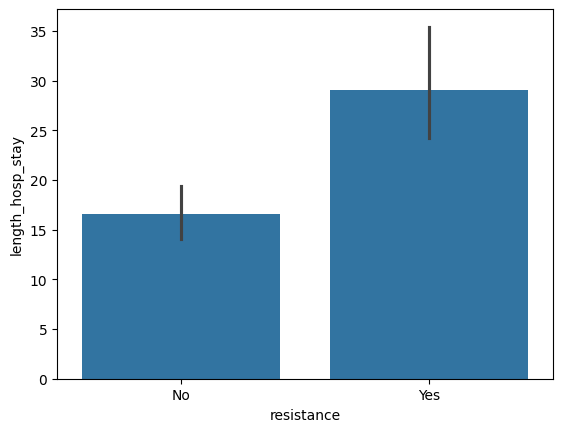

In [24]:
sns.barplot(data, x= 'resistance', y = 'length_hosp_stay')

# Filling missingness

## Infections sites

In [25]:
def infection_missing(df) :
    for col in ['Infection_Site_1', 'Infection_Site_2', 'Infection_Site_3']:
        if pd.isna(df[col]):
            df[col] = 'No infection'
    return df

data = data.apply(infection_missing, axis = 1)

## Prio antibiotics taken

In [26]:
def prio_antib_missing(df) :
    for col in ['Prio_antib_1', 'Prio_antib_2', 'Prio_antib_3', 'Prio_antib_4']:
        if pd.isna(df[col]):
            df[col] = 'UNK'
    return df

data = data.apply(prio_antib_missing, axis = 1)

## Cormobidity

In [27]:
def cormobidity_missing(df) :
    for col in ['Comobidity1', 'Comobidity2', 'Comobidity3']:
        if pd.isna(df[col]):
            df[col] = 'UNK'
    return df

data = data.apply(cormobidity_missing, axis = 1)

## Antibiotic prescribed

In [28]:
def Prescribed_antib_missing(df) :
    for col in ['Prescribed_antib_1', 'Prescribed_antib_2', 'Prescribed_antib_3', 'Prescribed_antib_4', 'Prescribed_antib_5']:
        if pd.isna(df[col]):
            df[col] = 'No antibiotic prescribed'
    return df

data = data.apply(Prescribed_antib_missing, axis = 1)

## Pathogens

In [29]:
def pathogen_missing(df) :
    for col in ['first_organism', 'sec_organism', 'third_organism']:
        if pd.isna(df[col]):
            df[col] = 'No pathogen'
    return df

data = data.apply(pathogen_missing, axis = 1)

## Antibiotics after culture

In [30]:
def antib_aft_missing(df) :
    for col in ['Antibioitic_aft_cul_1', 'Antibioitic_aft_cul_2']:
        if pd.isna(df[col]):
            df[col] = 'No antibiotic precibed'
    return df

data = data.apply(antib_aft_missing, axis = 1)

## antibiotics

In [31]:
def Antibiotics(df) :
    for col in ['antibiotics']:
        if pd.isna(df[col]):
            df[col] = 'No'
    return df

data = data.apply(Antibiotics, axis = 1)

## antibiotics after culture (Yes/No)

In [32]:
def Antibiotics_aft(df) :
    for col in ['antib_aft_culture']:
        if pd.isna(df[col]):
            df[col] = 'No'
    return df

data = data.apply(Antibiotics_aft, axis = 1)

## Complications

In [33]:
def Complications(df) :
    for col in ['complications']:
        if pd.isna(df[col]):
            df[col] = 'No'
    return df

data = data.apply(Complications, axis = 1)

## length of hospital stay

In [34]:
data.dropna(subset = 'length_hosp_stay', inplace = True)

# Encoding data

## Label Encoding

In [35]:
from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()

In [36]:
columns_to_encode = data.drop(columns = ['age', 'length_hosp_stay', 'referral', 'sex', 'intubated', 'antibiotics', 'Resistance1 ', 'Resistance2', 'Resistance3', 'antib_aft_culture', 'complications'])

for column in columns_to_encode:
    data[column] = Le.fit_transform(data[column])

## One hot encoding

In [37]:
#sex
data['sex'] = data['sex'].replace({'Male': 0, 'Female': 1})

In [38]:
data = data.replace ({'Yes': 1, "No": 0})

In [39]:
data.tail()

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,Prio_antib_1,...,Resistance2,third_organism,Resistance3,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,resistance
594,8,2.0,1,7,4,2,0,7,1,0,...,0,3,0,0,15,10,0,0,10.0,0
595,8,27.0,1,10,4,2,0,3,2,13,...,0,3,0,0,15,10,0,0,3.0,1
596,8,20.0,1,10,4,2,0,3,1,0,...,0,3,0,0,15,10,0,0,6.0,0
597,8,24.0,1,10,4,2,1,3,1,0,...,0,3,0,0,15,10,0,1,8.0,0
598,8,2.0,1,6,4,2,0,7,1,0,...,0,3,0,1,7,6,0,0,21.0,1


# Correlation 

Correaltion with the target variable and also how the different variable correlate with each other

/tmp/ipykernel_11079/848355969.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='RdBu')


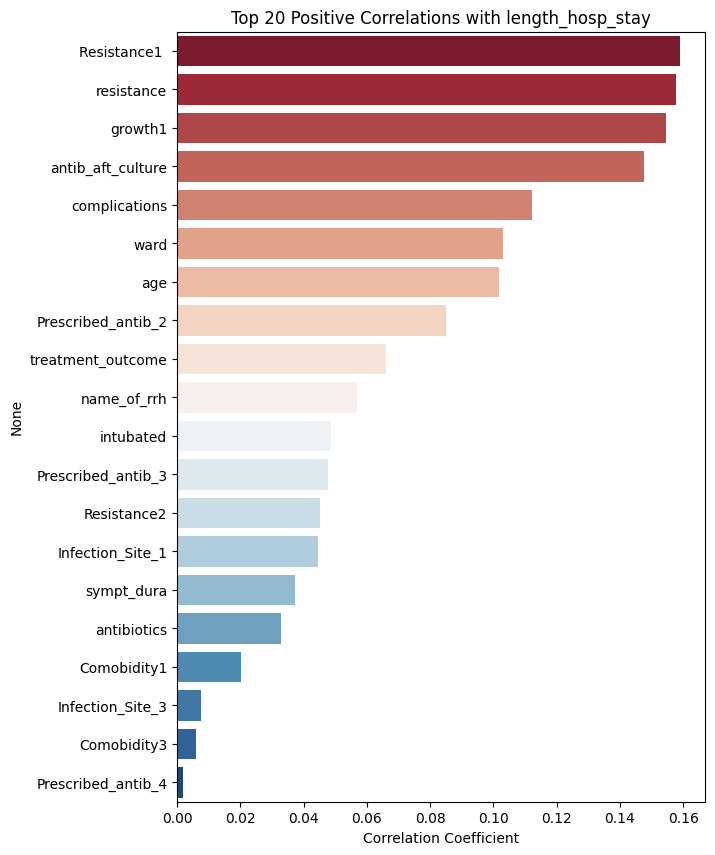

In [40]:
def plot_correlations(df, target_column, n_top = 39):
    
    # Calculate correlations with target variable
    correlations = df.corr()[target_column].sort_values(ascending=False)
    
    # Get top N most correlated features (excluding the target itself)
    top_corr = correlations[1:n_top+1]
    
    # Create figure with two subplots
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Horizontal bar chart of top correlations
    plt.subplot(1, 2, 1)
    sns.barplot(x=top_corr.values, y=top_corr.index, palette='RdBu')
    plt.title(f'Top {n_top} Positive Correlations with {target_column}')
    plt.xlabel('Correlation Coefficient')

plot_correlations(data, 'length_hosp_stay', n_top=20)

<Figure size 1500x1000 with 0 Axes>

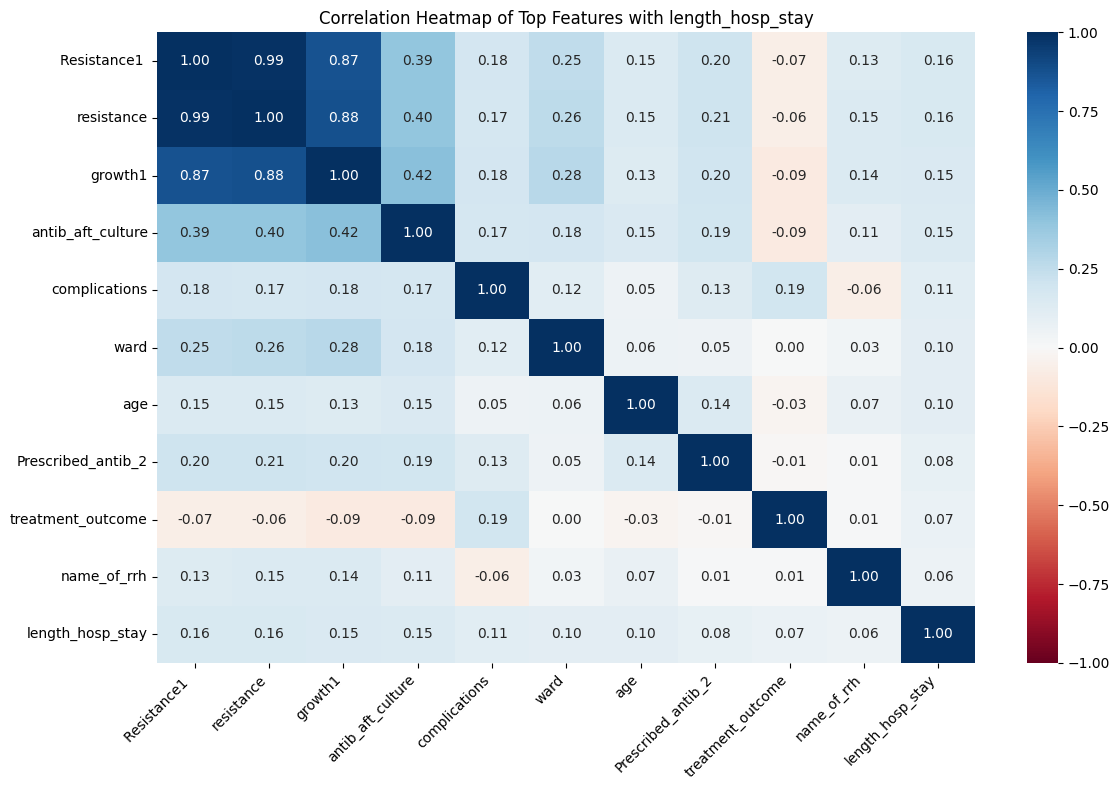

In [41]:
def plot_correlations(df, target_column, n_top=20):
    
    # Calculate correlations with target variable
    correlations = df.corr()[target_column].sort_values(ascending=False)
    
    # Get top N most correlated features (excluding the target itself)
    top_corr = correlations[1:n_top+1]
    #bottom_corr = correlations[-(n_top):]
    
    # Create figure with two subplots
    plt.figure(figsize=(15, 10))
    
    # Create heatmap of top correlated features
    plt.figure(figsize=(12, 8))
    top_features = list(top_corr.index[:10]) + [target_column]  # Top 10 + target
    correlation_matrix = df[top_features].corr()
    
    sns.heatmap(correlation_matrix, 
                annot=True,
                cmap='RdBu',
                vmin=-1, 
                vmax=1,
                center=0,
                fmt='.2f')
    plt.title(f'Correlation Heatmap of Top Features with {target_column}')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_correlations(data, 'length_hosp_stay', n_top=20)

# ML

## Data

In [42]:
growth = data[data['growth1']==1]

print(growth.shape)

growth.head()

(324, 40)


,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,Prio_antib_1,...,Resistance2,third_organism,Resistance3,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,resistance
3,0,18.0,0,10,4,2,1,9,1,0,...,0,3,0,0,15,10,1,1,0.0,1
4,0,17.0,1,10,4,2,1,3,1,0,...,0,3,0,1,6,10,1,1,10.0,1
5,0,29.0,0,7,4,2,1,9,1,0,...,1,0,1,1,11,10,0,1,69.0,1
8,0,50.0,1,9,4,2,1,9,1,0,...,0,3,0,0,15,10,0,2,5.0,1
11,0,30.0,1,7,4,2,0,6,1,0,...,0,3,0,0,15,10,0,0,45.0,1


In [43]:
growth.to_csv('Patients with growth.csv', index = False)

In [44]:
no_growth = data[data['growth1'] == 0]

print(no_growth.shape)

no_growth.head()

(272, 40)


,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,Prio_antib_1,...,Resistance2,third_organism,Resistance3,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,resistance
0,0,6.0,0,1,4,2,1,7,1,0,...,0,3,0,0,15,10,0,1,12.0,0
1,0,13.0,0,6,6,2,1,4,1,0,...,0,3,0,0,15,10,0,1,8.0,0
2,0,11.0,0,11,4,2,0,7,1,0,...,0,3,0,0,15,10,1,1,14.0,0
6,0,8.0,1,1,4,2,0,7,1,0,...,0,3,0,0,15,10,0,1,6.0,0
7,0,10.0,1,11,4,2,1,7,1,0,...,0,3,0,0,15,10,0,1,11.0,0


## Modelling

# Huber model

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns m

🏃 View run persistent-auk-983 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/94c18792d33d41dd95fe121bf2eb5899
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571
Mean Absolute Error: 16.94
Root Mean Squared Error: 27.78
R-squared Score: -0.0728


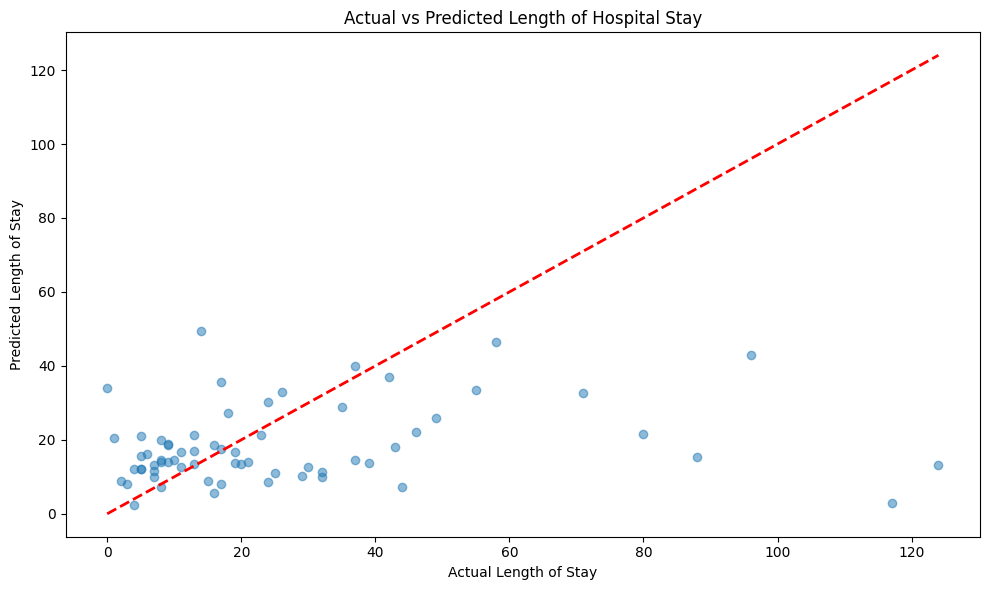

In [68]:
import mlflow
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters
params = {
    'epsilon': 1.75,
    'max_iter': 500,
    'alpha': 0.1
}

# Train the model
huber = HuberRegressor(**params)
huber.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = huber.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(huber, "huber_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay')
plt.tight_layout()
plt.show()

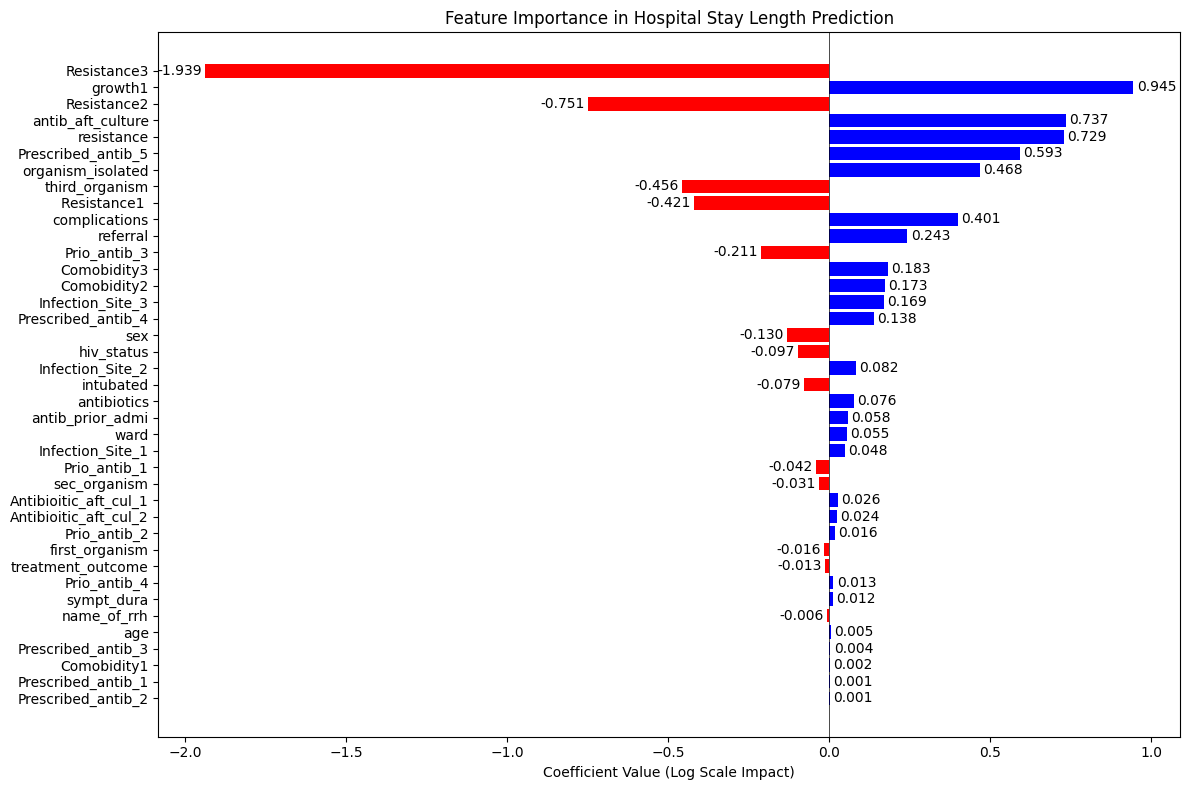


Feature Importance Rankings:
              feature  coefficient  abs_coefficient
          Resistance3    -1.939352         1.939352
              growth1     0.944921         0.944921
          Resistance2    -0.750543         0.750543
    antib_aft_culture     0.736588         0.736588
           resistance     0.728649         0.728649
   Prescribed_antib_5     0.592819         0.592819
    organism_isolated     0.467821         0.467821
       third_organism    -0.456399         0.456399
         Resistance1     -0.421074         0.421074
        complications     0.401119         0.401119
             referral     0.243104         0.243104
         Prio_antib_3    -0.211018         0.211018
          Comobidity3     0.183385         0.183385
          Comobidity2     0.173466         0.173466
     Infection_Site_3     0.169124         0.169124
   Prescribed_antib_4     0.137664         0.137664
                  sex    -0.130297         0.130297
           hiv_status    -0.097197

In [75]:
# Get feature names and coefficients
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': huber.coef_
})

# Sort by absolute value of coefficient while keeping the sign
feature_importance['abs_coef'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=True)

# Create a horizontal bar plot
plt.figure(figsize=(12, 8))
colors = ['red' if c < 0 else 'blue' for c in feature_importance['coefficient']]
bars = plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)

# Add vertical line at x=0
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Customize the plot
plt.title('Feature Importance in Hospital Stay Length Prediction')
plt.xlabel('Coefficient Value (Log Scale Impact)')

# Add value labels on the bars
for bar in bars:
    width = bar.get_width()
    label_x = width + (0.01 if width >= 0 else -0.01)
    plt.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}',
             ha='left' if width >= 0 else 'right', 
             va='center')

plt.tight_layout()
plt.show()

# Print detailed feature importance table
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)
print("\nFeature Importance Rankings:")
print(feature_importance[['feature', 'coefficient', 'abs_coefficient']].to_string(index=False))

# Calculate percentage influence
total_importance = feature_importance['abs_coefficient'].sum()
feature_importance['influence_percentage'] = (feature_importance['abs_coefficient'] / total_importance * 100)

print("\nTop 5 Most Influential Features:")
top_5 = feature_importance.head()
for _, row in top_5.iterrows():
    direction = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"{row['feature']}: {row['influence_percentage']:.1f}% influence ({direction} length of stay)")

In [69]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow huber model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Huber model")

    # Infer the model signature
    signature = infer_signature(X_train, huber.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="Huber_model",
    )

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'Huber_model' already exists. Creating a new version of this model...
2025/02/19 17:14:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Mode

🏃 View run calm-loon-138 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/aaa79f5fcc7c453d88e3ef2ca543cfcf
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


Created version '10' of model 'Huber_model'.


In [70]:
# Load the model back for predictions as a generic Python Function model
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

predictions = loaded_model.predict(X_test)

dataset_names = growth.columns

result = pd.DataFrame(X_test, columns=dataset_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:10]

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,Prio_antib_1,...,Resistance3,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,resistance,actual_class,predicted_class
277,4,18.0,1,10,4,2,0,0,1,0,...,0,0,15,10,0,1,NaN,1,3.401197,2.422382
230,3,0.0,1,6,4,2,0,7,1,0,...,0,0,15,10,0,2,NaN,1,2.079442,2.532853
286,4,39.0,0,7,4,2,0,9,0,0,...,0,1,5,10,0,1,NaN,1,4.025352,3.541278
20,0,21.0,1,5,4,2,0,3,1,0,...,0,0,15,10,0,1,NaN,1,1.386294,2.203867
377,5,47.0,0,5,4,2,0,9,0,0,...,0,0,15,10,0,0,NaN,1,3.091042,2.702273
264,4,30.0,1,1,8,2,0,4,1,0,...,0,0,15,10,0,2,NaN,0,1.609438,2.580865
446,6,22.0,1,8,4,2,0,9,1,0,...,0,1,6,9,0,0,NaN,1,4.828314,2.656886
400,5,0.0,1,11,4,2,0,2,0,0,...,0,0,15,10,0,0,NaN,1,1.098612,2.279111
510,7,80.0,0,2,4,2,0,4,0,0,...,0,1,5,10,0,0,NaN,1,3.637586,2.751788
302,4,43.0,1,7,4,2,0,9,1,0,...,0,1,6,6,0,1,NaN,1,4.394449,3.118593


## Hyperparameter tuning

In [50]:
import optuna

def objective(trial):
    """Function to optimize hyperparameters."""
    with mlflow.start_run():
        # Suggest hyperparameters
        epsilon = trial.suggest_float("epsilon", 1.1, 2.0)
        max_iter = trial.suggest_int("max_iter", 500, 2000, step=500)
        alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
        
        # Train the model
        model = HuberRegressor(epsilon=epsilon, max_iter=max_iter, alpha=alpha)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Compute metric
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Log parameters and metrics to MLflow
        mlflow.log_params({"epsilon": epsilon, "max_iter": max_iter, "alpha": alpha})
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric('MSE', mse)
        mlflow.log_metric('R2', r2)

        return mae  # Optuna minimizes this

# Run optimization
study = optuna.create_study(direction="minimize")  # Minimize MAE
study.optimize(objective, n_trials=20)

# Print best parameters
print("Best parameters:", study.best_params)


[I 2025-02-19 15:22:04,777] A new study created in memory with name: no-name-00a73474-b4d1-478c-8b11-bc7f4ec06c03
/tmp/ipykernel_11079/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
[I 2025-02-19 15:22:22,597] Trial 0 finished with value: 17.817220034577538 and parameters: {'epsilon': 1.1994315123714911, 'max_iter': 2000, 'alpha': 0.006310266414178671}

🏃 View run casual-calf-123 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/7739ce3f4fea44b1b7aa101d72b81026
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


/tmp/ipykernel_11079/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
[I 2025-02-19 15:22:41,572] Trial 1 finished with value: 18.997663931934053 and parameters: {'epsilon': 1.3028193708660238, 'max_iter': 2000, 'alpha': 0.00013455282761404402}. Best is trial 0 with value: 17.817220034577538.


🏃 View run omniscient-boar-949 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/ad01d589105d4b0b94d38b1690486bd0
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


/tmp/ipykernel_11079/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
[I 2025-02-19 15:22:46,633] Trial 2 finished with value: 18.253088669263768 and parameters: {'epsilon': 1.9314780054636413, 'max_iter': 500, 'alpha': 2.637068899399174e-05}. Best is trial 0 with value: 17.817220034577538.


...

🏃 View run serious-goose-368 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/10c84fac96474a1bbdc9ce04a198fffa
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


/tmp/ipykernel_11079/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
[I 2025-02-19 15:26:28,669] Trial 18 finished with value: 18.915680654687225 and parameters: {'epsilon': 1.2379295050789778, 'max_iter': 1500, 'alpha': 0.0009394189353854124}. Best is trial 12 with value: 17.235931746742576.


🏃 View run monumental-skink-726 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/f33fe6376f9443aa88ab87a41bbcd93d
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571


/tmp/ipykernel_11079/1007683687.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-5, 1e-2)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
[I 2025-02-19 15:26:44,339] Trial 19 finished with value: 17.726165069387655 and parameters: {'epsilon': 1.1908786903129034, 'max_iter': 1000, 'alpha': 0.004679502278096848}. Best is trial 12 with value: 17.235931746742576.


🏃 View run useful-ant-642 at: http://127.0.0.1:8080/#/experiments/993118495688724571/runs/69112c74ebfa4c7cb02c56e425bb2165
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/993118495688724571
Best parameters: {'epsilon': 1.1466513146809405, 'max_iter': 500, 'alpha': 0.0025400255438395992}


In [53]:
# Load the model back for predictions as a generic Python Function model
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

predictions = loaded_model.predict(X_test)

dataset_names = growth.columns

result = pd.DataFrame(X_test, columns=dataset_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:10]

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,Prio_antib_1,...,Resistance3,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,resistance,actual_class,predicted_class
277,4,18.0,1,10,4,2,0,0,1,0,...,0,0,15,10,0,1,NaN,1,29.0,11.802336
230,3,0.0,1,6,4,2,0,7,1,0,...,0,0,15,10,0,2,NaN,1,7.0,11.656402
286,4,39.0,0,7,4,2,0,9,0,0,...,0,1,5,10,0,1,NaN,1,55.0,18.538108
20,0,21.0,1,5,4,2,0,3,1,0,...,0,0,15,10,0,1,NaN,1,3.0,6.338146
377,5,47.0,0,5,4,2,0,9,0,0,...,0,0,15,10,0,0,NaN,1,21.0,17.088410
264,4,30.0,1,1,8,2,0,4,1,0,...,0,0,15,10,0,2,NaN,0,4.0,18.807819
446,6,22.0,1,8,4,2,0,9,1,0,...,0,1,6,9,0,0,NaN,1,124.0,15.803218
400,5,0.0,1,11,4,2,0,2,0,0,...,0,0,15,10,0,0,NaN,1,2.0,7.857235
510,7,80.0,0,2,4,2,0,4,0,0,...,0,1,5,10,0,0,NaN,1,37.0,14.893205
302,4,43.0,1,7,4,2,0,9,1,0,...,0,1,6,6,0,1,NaN,1,80.0,27.782414


Fitting 5 folds for each of 25 candidates, totalling 125 fits


/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL N

Best parameters: {'alpha': 0.1, 'epsilon': 1.75, 'max_iter': 500}
Best cross-validation score (RMSE): 1.012782177063247

Top 5 parameter combinations:
                                               params      rmse  \
23   {'alpha': 0.1, 'epsilon': 1.75, 'max_iter': 500}  1.012782   
19   {'alpha': 0.05, 'epsilon': 2.0, 'max_iter': 500}  1.013192   
4   {'alpha': 0.001, 'epsilon': 2.0, 'max_iter': 500}  1.014762   
9   {'alpha': 0.005, 'epsilon': 2.0, 'max_iter': 500}  1.014794   
3   {'alpha': 0.001, 'epsilon': 1.75, 'max_iter': ...  1.015114   

    std_test_score  
23        0.107500  
19        0.121137  
4         0.113032  
9         0.116435  
3         0.108839  


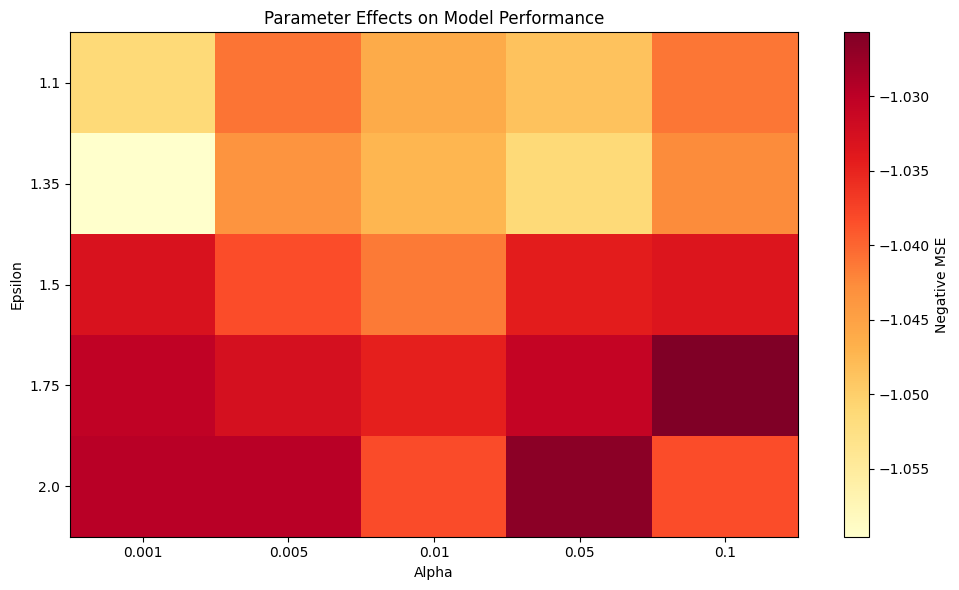

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



Feature Importances:
                  feature  coefficient
32            Resistance3    -1.059110
26                growth1     0.813814
24     Prescribed_antib_5    -0.812665
33      antib_aft_culture     0.704712
38             resistance     0.673905
18            Comobidity3     0.551177
30            Resistance2    -0.526150
36          complications     0.437901
28           Resistance1     -0.356999
25      organism_isolated     0.232500
31         third_organism    -0.213524
6                referral     0.167791
5        Infection_Site_3     0.160112
11           Prio_antib_3    -0.148876
12           Prio_antib_4    -0.132281
2                     sex    -0.125011
23     Prescribed_antib_4     0.110034
19            antibiotics    -0.097622
8        antib_prior_admi     0.088524
4        Infection_Site_2     0.064257
3        Infection_Site_1     0.050387
37      treatment_outcome    -0.046749
7                    ward     0.045184
9            Prio_antib_1    -0.042108
29 

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL N


Cross-validation RMSE scores:
Mean RMSE: 1.0045 (+/- 0.1104)


/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/sklearn/linear_model/_huber.py:296: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [64]:
from sklearn.model_selection import GridSearchCV

# Prepare the data (using log transform as before)
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])

# Define parameter grid
param_grid = {
    'epsilon': [1.1, 1.35, 1.5, 1.75, 2.0],
    'alpha': [0.001, 0.005, 0.01, 0.05, 0.1],
    'max_iter': [500]  # Fixed as it's more of a computational parameter
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    HuberRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X, y)

# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score (RMSE):", np.sqrt(-grid_search.best_score_))

# Get detailed results
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')

# Print top 5 parameter combinations
print("\nTop 5 parameter combinations:")
top_5 = cv_results[['params', 'mean_test_score', 'std_test_score']].head()
top_5['rmse'] = np.sqrt(-top_5['mean_test_score'])
print(top_5[['params', 'rmse', 'std_test_score']])

# Plot parameter effects
import matplotlib.pyplot as plt

# Create epsilon vs alpha heatmap
pivot_table = cv_results.pivot_table(
    values='mean_test_score',
    index='param_epsilon',
    columns='param_alpha'
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot_table, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Negative MSE')
plt.xticks(range(len(param_grid['alpha'])), param_grid['alpha'])
plt.yticks(range(len(param_grid['epsilon'])), param_grid['epsilon'])
plt.xlabel('Alpha')
plt.ylabel('Epsilon')
plt.title('Parameter Effects on Model Performance')
plt.tight_layout()
plt.show()

# Train final model with best parameters
best_model = HuberRegressor(**grid_search.best_params_)
best_model.fit(X, y)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.coef_
})
feature_importance = feature_importance.sort_values('coefficient', key=abs, ascending=False)

print("\nFeature Importances:")
print(feature_importance)

# Validate the model using cross-validation scores
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)

print("\nCross-validation RMSE scores:")
print(f"Mean RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std() * 2:.4f})")

# Random Forest Regressor


/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run bemused-wolf-15 at: http://127.0.0.1:8080/#/experiments/320510952361426209/runs/2c7db0cae8f2430ba7daf1a1f2c26110
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/320510952361426209
Mean Absolute Error: 15.34
Root Mean Squared Error: 25.78
R-squared Score: 0.0760


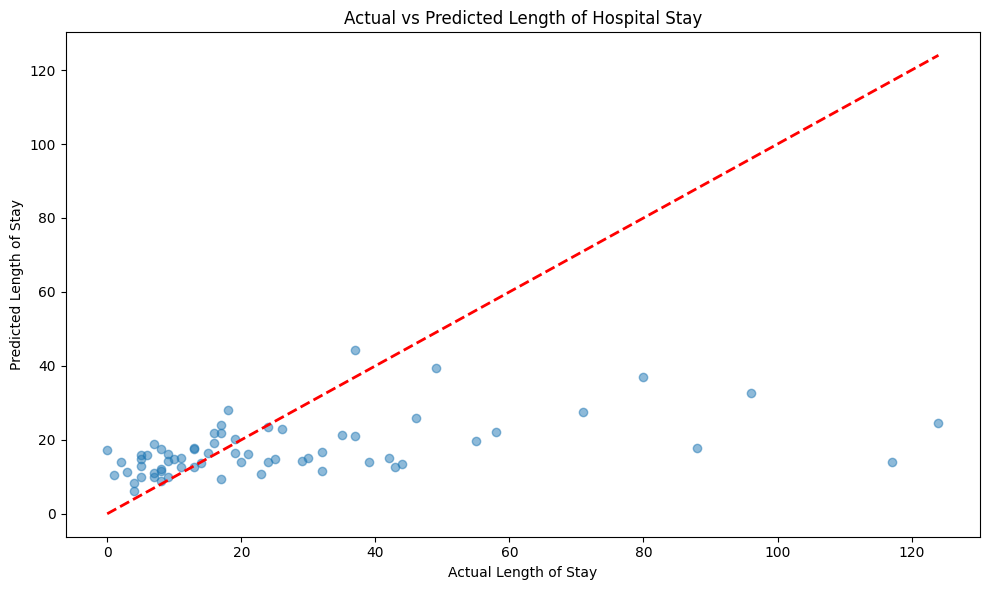

In [91]:
import mlflow
from mlflow.models import infer_signature
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Apply log transformation to the target variable
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])  # Using log1p to handle zero values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the model hyperparameters
params = {
    'n_estimators': 750, 
    'min_samples_split': 2, 
    'min_samples_leaf': 4, 
    'max_features': 0.8, 
    'max_depth': None, 
    'bootstrap': True
}


# Train the model
rf = RandomForestRegressor(**params)
rf.fit(X_train, y_train)

# Make predictions and inverse transform them
y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Inverse transform the predictions
y_test_original = np.expm1(y_test)  # Inverse transform the test data

# Calculate metrics on the original scale
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

# Log the model and metrics with MLflow
with mlflow.start_run():
    mlflow.log_params(params)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    
    # Log the model with input and output signatures
    signature = infer_signature(X_train, y_pred)
    mlflow.sklearn.log_model(rf, "Rf_regressor_model", signature=signature)

# Print the metrics
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Optional: Create a scatter plot to visualize predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.xlabel('Actual Length of Stay')
plt.ylabel('Predicted Length of Stay')
plt.title('Actual vs Predicted Length of Hospital Stay')
plt.tight_layout()
plt.show()

In [92]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

# Create a new MLflow Experiment
mlflow.set_experiment("MLflow RandomForest Regressor model")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Random Forest Regressor model")

    # Infer the model signature
    signature = infer_signature(X_train, huber.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=huber,
        artifact_path="growth",
        signature=signature,
        input_example=X_train,
        registered_model_name="RandomForest Regressor model",
    )

/home/racheal/ENTER/envs/mlflow_env/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'RandomForest Regressor model' already exists. Creating a new version of this model...
2025/02/20 11:33:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to fini

🏃 View run capricious-steed-342 at: http://127.0.0.1:8080/#/experiments/320510952361426209/runs/8b086b4767c44a6d99e4affe27bad689
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/320510952361426209


In [93]:
# Load the model back for predictions as a generic Python Function model
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

predictions = loaded_model.predict(X_test)

dataset_names = growth.columns

result = pd.DataFrame(X_test, columns=dataset_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:10]

,name_of_rrh,age,sex,Infection_Site_1,Infection_Site_2,Infection_Site_3,referral,ward,antib_prior_admi,Prio_antib_1,...,Resistance3,antib_aft_culture,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,complications,treatment_outcome,length_hosp_stay,resistance,actual_class,predicted_class
277,4,18.0,1,10,4,2,0,0,1,0,...,0,0,15,10,0,1,NaN,1,3.401197,2.422382
230,3,0.0,1,6,4,2,0,7,1,0,...,0,0,15,10,0,2,NaN,1,2.079442,2.532853
286,4,39.0,0,7,4,2,0,9,0,0,...,0,1,5,10,0,1,NaN,1,4.025352,3.541278
20,0,21.0,1,5,4,2,0,3,1,0,...,0,0,15,10,0,1,NaN,1,1.386294,2.203867
377,5,47.0,0,5,4,2,0,9,0,0,...,0,0,15,10,0,0,NaN,1,3.091042,2.702273
264,4,30.0,1,1,8,2,0,4,1,0,...,0,0,15,10,0,2,NaN,0,1.609438,2.580865
446,6,22.0,1,8,4,2,0,9,1,0,...,0,1,6,9,0,0,NaN,1,4.828314,2.656886
400,5,0.0,1,11,4,2,0,2,0,0,...,0,0,15,10,0,0,NaN,1,1.098612,2.279111
510,7,80.0,0,2,4,2,0,4,0,0,...,0,1,5,10,0,0,NaN,1,3.637586,2.751788
302,4,43.0,1,7,4,2,0,9,1,0,...,0,1,6,6,0,1,NaN,1,4.394449,3.118593


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:
{'n_estimators': 750, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': None, 'bootstrap': True}

Best RMSE: 38.79120862476067

Top 5 parameter combinations:

Rank 1:
Parameters: {'n_estimators': 750, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': None, 'bootstrap': True}
RMSE: 38.79 (+/- 57.20)

Rank 2:
Parameters: {'n_estimators': 1250, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': 10, 'bootstrap': True}
RMSE: 38.79 (+/- 57.28)

Rank 3:
Parameters: {'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': 30, 'bootstrap': True}
RMSE: 38.80 (+/- 57.24)

Rank 4:
Parameters: {'n_estimators': 1000, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': 10, 'bootstrap': True}
RMSE: 38.80 (+/- 57.28)

Rank 5:
Parameters: {'n_estimators':

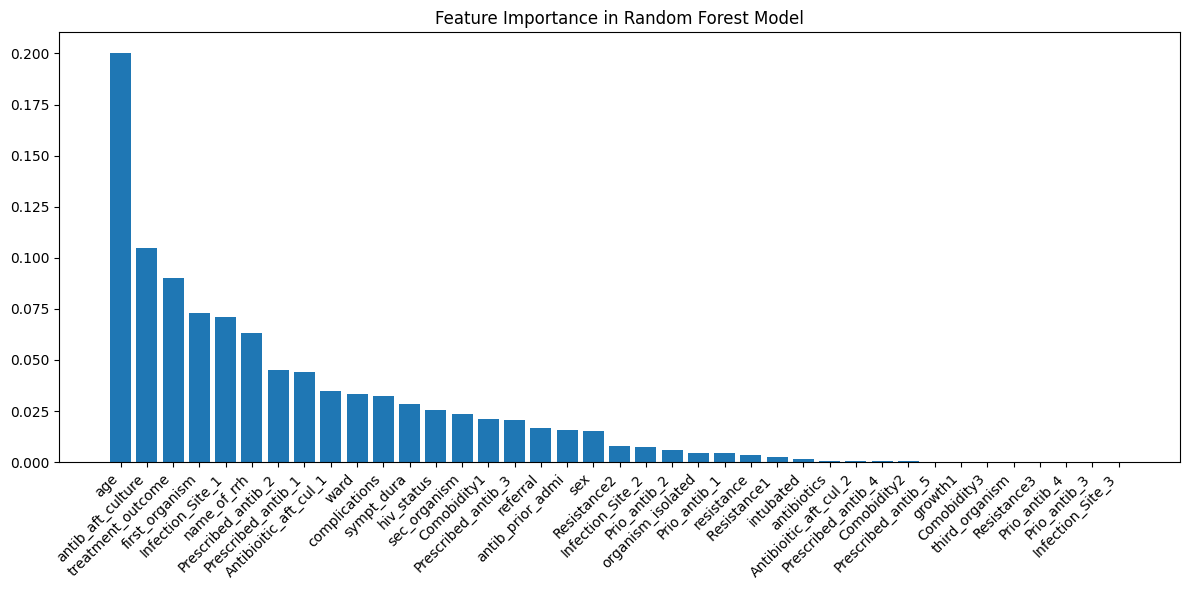

In [90]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error
import pandas as pd

# Prepare the data
X = growth.drop(columns='length_hosp_stay')
y = np.log1p(growth['length_hosp_stay'])

# Define custom scorer for original scale RMSE
def custom_rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

rmse_scorer = make_scorer(custom_rmse_scorer, greater_is_better=False)

# Define parameter distributions
param_dist = {
    'n_estimators': [500, 750, 1000, 1250],
    'max_features': [0.6, 0.7, 0.8, 0.9],
    'min_samples_split': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_depth': [None, 10, 20, 30],
    'bootstrap': [True, False]
}

# Create Random Forest model
rf = RandomForestRegressor(random_state=1)

# Perform randomized search
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring=rmse_scorer,
    n_jobs=-1,
    random_state=1,
    verbose=1
)

# Fit the random search
random_search.fit(X, y)

# Print results
print("Best parameters found:")
print(random_search.best_params_)
print("\nBest RMSE:", -random_search.best_score_)

# Get all results
results = pd.DataFrame(random_search.cv_results_)
results = results.sort_values('mean_test_score', ascending=False)

# Print top 5 combinations
print("\nTop 5 parameter combinations:")
for i in range(5):
    params = results.iloc[i]['params']
    score = -results.iloc[i]['mean_test_score']
    std = results.iloc[i]['std_test_score']
    print(f"\nRank {i+1}:")
    print(f"Parameters: {params}")
    print(f"RMSE: {score:.2f} (+/- {std*2:.2f})")

# Train best model and get feature importance
best_model = RandomForestRegressor(**random_search.best_params_, random_state=1)
best_model.fit(X, y)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\nFeature Importance with Best Parameters:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 6))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance in Random Forest Model')
plt.tight_layout()
plt.show()